In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/head_head_approach_angles.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/head_head_approach_angles.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/head_head_approach_angles.csv')
df3['Condition'] = 'GH Starved-Starved'


df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/head_head_approach_angles.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/head_head_approach_angles.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/head_head_approach_angles.csv')
df6['Condition'] = 'SI Starved-Starved'


df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)

si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()

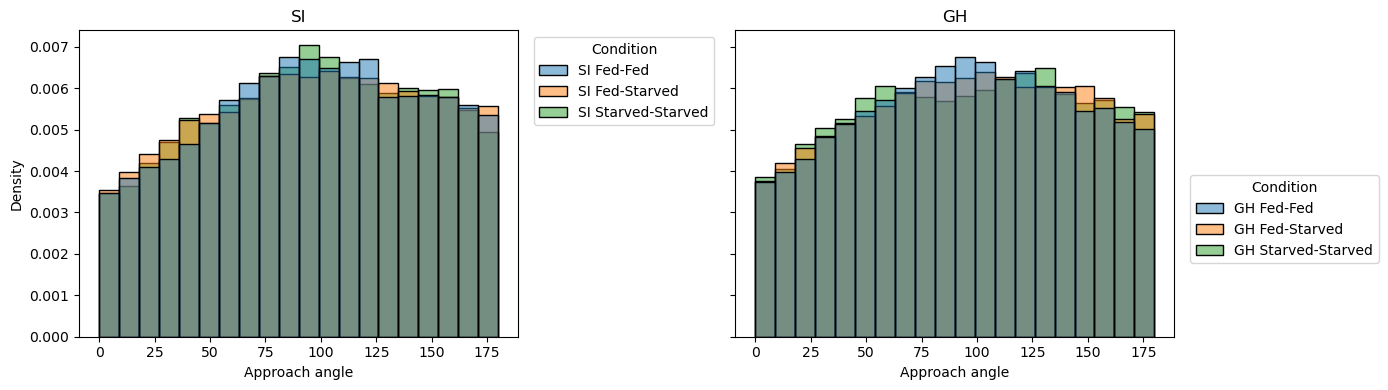

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14,4), sharey=True)

# SI
sns.histplot(
    data=si,
    x='approach_angle',
    hue='Condition',
    bins=20,
    stat='density',
    common_norm=False,
    ax=axes[0]
)

axes[0].set_title('SI')
axes[0].set_xlabel('Approach angle')
axes[0].set_ylabel('Density')

sns.move_legend(
    axes[0],
    "upper left",
    bbox_to_anchor=(1.02, 1)
)

# GH
sns.histplot(
    data=gh,
    x='approach_angle',
    hue='Condition',
    bins=20,
    stat='density',
    common_norm=False,
    ax=axes[1]
)

axes[1].set_title('GH')
axes[1].set_xlabel('Approach angle')
axes[1].set_ylabel('')

sns.move_legend(
    axes[1],
    "upper left",
    bbox_to_anchor=(1.02, 0.55)
)

plt.tight_layout()
plt.show()

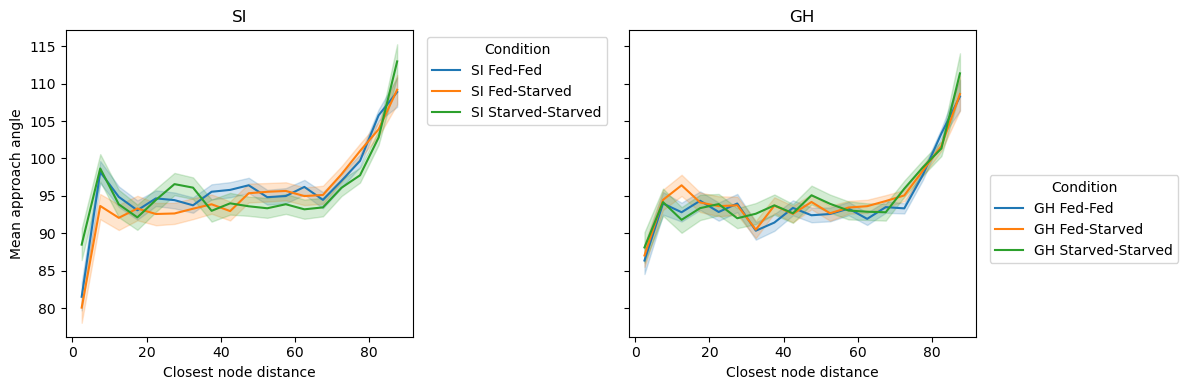

In [5]:
# bin distances
df['distance_bin'] = pd.cut(
    df['closest_other_node_distance'],
    bins=np.arange(0, 91, 5)
)

# bin centres
df['distance_bin_center'] = (
    df['distance_bin']
      .apply(lambda x: x.mid)
)

# recreate subsets AFTER new columns exist
si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# SI
sns.lineplot(
    data=si,
    x='distance_bin_center',
    y='approach_angle',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('SI')
axes[0].set_xlabel('Closest node distance')
axes[0].set_ylabel('Mean approach angle')

# GH
sns.lineplot(
    data=gh,
    x='distance_bin_center',
    y='approach_angle',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('GH')
axes[1].set_xlabel('Closest node distance')
axes[1].set_ylabel('')

sns.move_legend(
    axes[0],
    "upper left",
    bbox_to_anchor=(1.02, 1)
)

sns.move_legend(
    axes[1],
    "upper left",
    bbox_to_anchor=(1.02, 0.55)
)

plt.tight_layout()
plt.show()

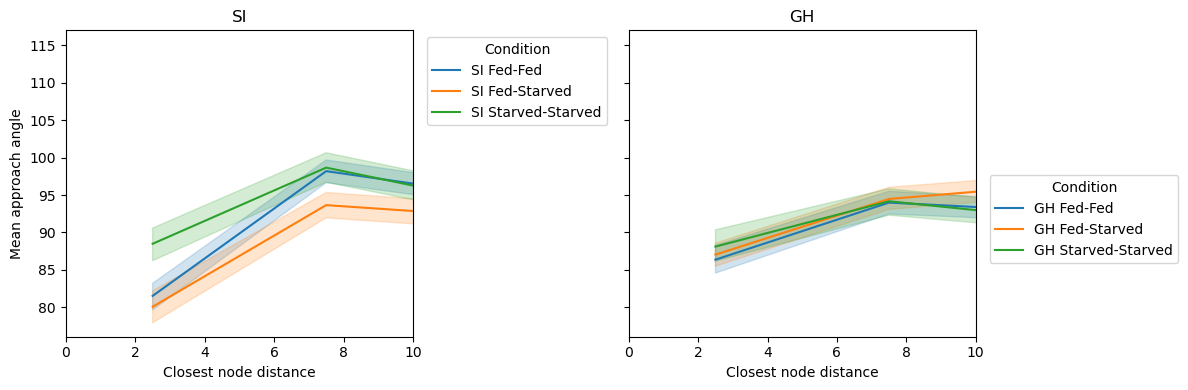

In [6]:
# bin distances
df['distance_bin'] = pd.cut(
    df['closest_other_node_distance'],
    bins=np.arange(0, 91, 5)
)

# bin centres
df['distance_bin_center'] = (
    df['distance_bin']
      .apply(lambda x: x.mid)
)

# recreate subsets AFTER new columns exist
si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# SI
sns.lineplot(
    data=si,
    x='distance_bin_center',
    y='approach_angle',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('SI')
axes[0].set_xlabel('Closest node distance')
axes[0].set_ylabel('Mean approach angle')
axes[0].set_xlim(0, 10)

# GH
sns.lineplot(
    data=gh,
    x='distance_bin_center',
    y='approach_angle',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('GH')
axes[1].set_xlabel('Closest node distance')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 10)

sns.move_legend(
    axes[0],
    "upper left",
    bbox_to_anchor=(1.02, 1)
)

sns.move_legend(
    axes[1],
    "upper left",
    bbox_to_anchor=(1.02, 0.55)
)

plt.tight_layout()
plt.show()